Лабораторная работа № 3. Выполнила: Шишкина Валерия Алексеевна, 3825М1ФИ2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import pairwise_distances
from sklearn.datasets import load_digits
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
digits = load_digits()
X = digits.data
y = digits.target

In [4]:
X, y

(array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 array([0, 1, 2, ..., 8, 9, 8]))

In [5]:
X.shape, y.shape

((1797, 64), (1797,))

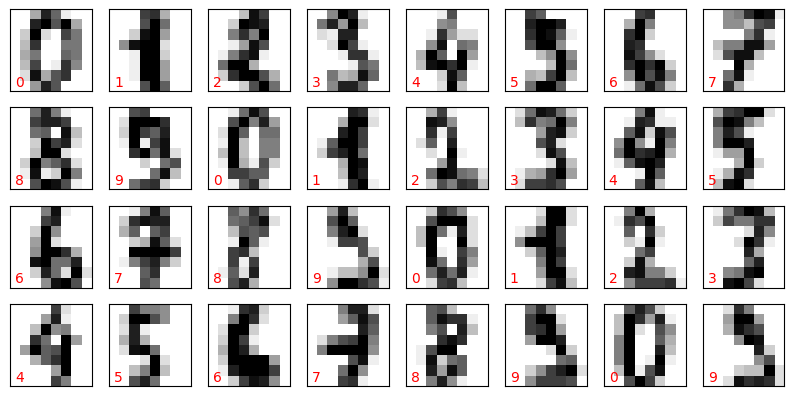

In [6]:
plt.figure(figsize = (10, 10))
for i in range(32):
    plt.subplot(8, 8, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(np.reshape(X[i, :], (8, 8)), interpolation = 'nearest', cmap='binary')
    plt.text(0, 7, str(digits.target[i]), color = 'red')

In [7]:
pca = PCA(n_components = 0.95, random_state = 42)
X_pca = pca.fit_transform(X)
X_pca.shape

(1797, 29)

In [8]:
X_2d = PCA(n_components = 2, random_state = 42).fit_transform(X)
X_2d.shape

(1797, 2)

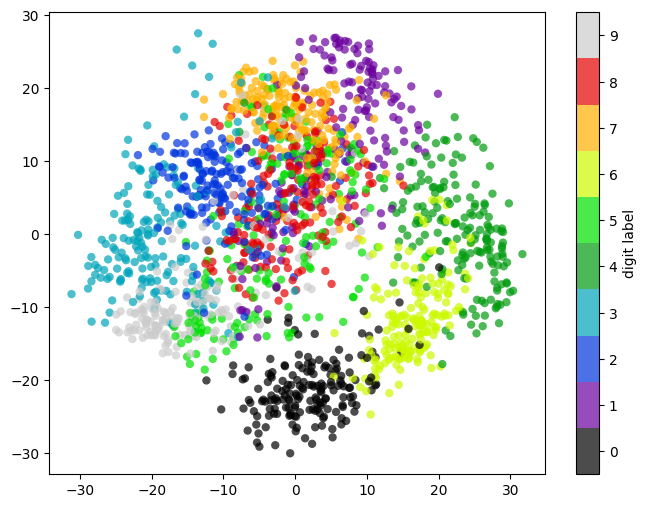

In [9]:
plt.figure(figsize = (8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = digits.target,
            edgecolor = 'none', alpha = .7)
plt.set_cmap(plt.cm.get_cmap('nipy_spectral', 10))
plt.colorbar(label = 'digit label', ticks = range(10))
plt.clim(-0.5, 9.5)

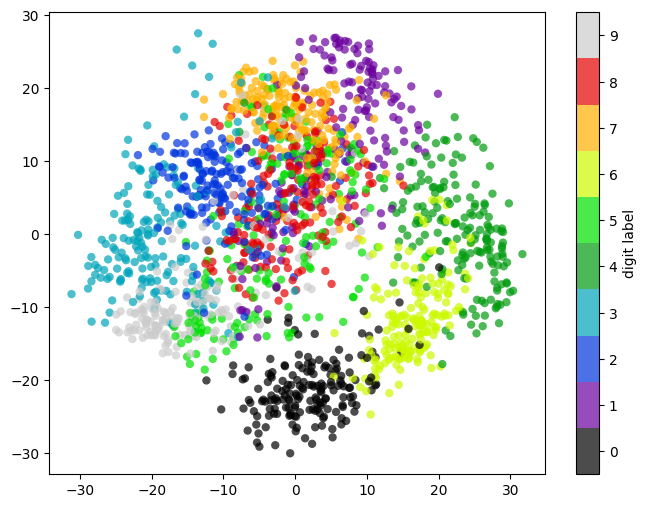

In [10]:
plt.figure(figsize = (8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c = digits.target,
            edgecolor = 'none', alpha = .7)
plt.set_cmap(plt.cm.get_cmap('nipy_spectral', 10))
plt.colorbar(label = 'digit label', ticks = range(10))
plt.clim(-0.5, 9.5)

In [11]:
kmeans_x = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred_kmeans_x= kmeans_x.fit_predict(X)

In [12]:
ari_kmeans_x = adjusted_rand_score(y, y_pred_kmeans_x)
print(f"{ari_kmeans_x:.2f}")

0.67


In [13]:
X_scaled = StandardScaler().fit_transform(X)

In [14]:
kmeans_scaled = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred_kmeans_scaled = kmeans_scaled.fit_predict(X_scaled)

In [15]:
ari_scaled = adjusted_rand_score(y, y_pred_kmeans_scaled)
print(f"{ari_scaled:.2f}")

0.53


In [16]:
kmeans_pca = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred_kmeans_pca = kmeans_pca.fit_predict(X_pca)

In [17]:
ari_pca = adjusted_rand_score(y, y_pred_kmeans_pca)
print(f"{ari_pca:.2f}")

0.66


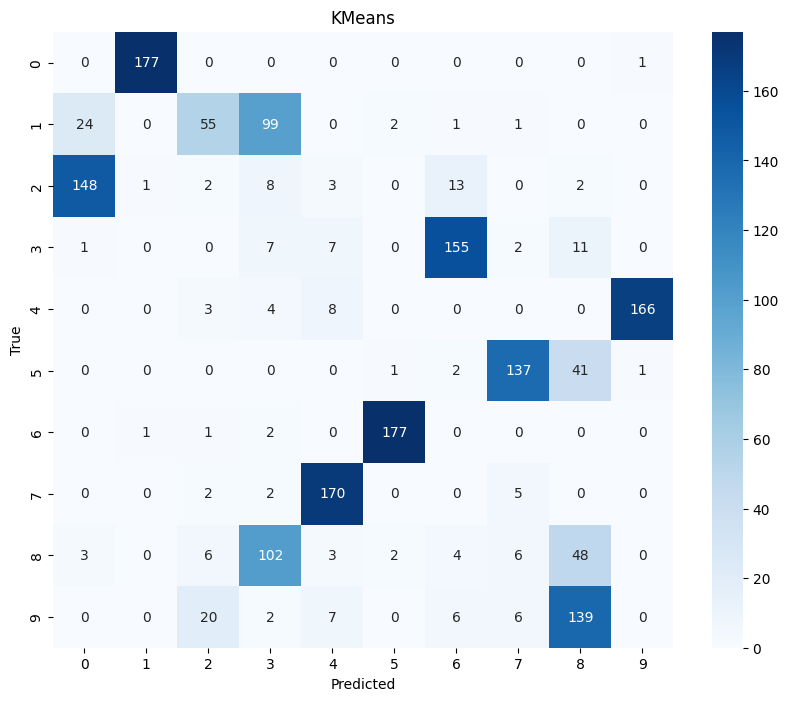

In [18]:
cm_kmeans = confusion_matrix(y, y_pred_kmeans_x)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_kmeans, annot=True, fmt='d', cmap='Blues')
plt.title('KMeans')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [19]:
row_ind, col_ind = linear_sum_assignment(cm_kmeans.max() - cm_kmeans)

cluster_to_digit = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}

for cluster_id in sorted(cluster_to_digit.keys()):
    digit = cluster_to_digit[cluster_id]
    print(f"Кластер {cluster_id} → Цифра {digit}")

y_pred_mapped_kmeans = np.array([cluster_to_digit[i] for i in y_pred_kmeans_x])

Кластер 0 → Цифра 2
Кластер 1 → Цифра 0
Кластер 2 → Цифра 1
Кластер 3 → Цифра 8
Кластер 4 → Цифра 7
Кластер 5 → Цифра 6
Кластер 6 → Цифра 3
Кластер 7 → Цифра 5
Кластер 8 → Цифра 9
Кластер 9 → Цифра 4


In [20]:
_kmeans = sum(y==y_pred_mapped_kmeans)/len(y_pred_mapped_kmeans)
print(f"{_kmeans:.2f}")

0.79


In [21]:
gmm = GaussianMixture(
    n_components=10,
    covariance_type='full',
    random_state=42,
    max_iter=200,
    n_init=20
)
y_pred_gmm_pca = gmm.fit_predict(X_pca)

In [22]:
ari_pca_gmm = adjusted_rand_score(y, y_pred_gmm_pca)
print(f"{ari_pca_gmm:.2f}")

0.71


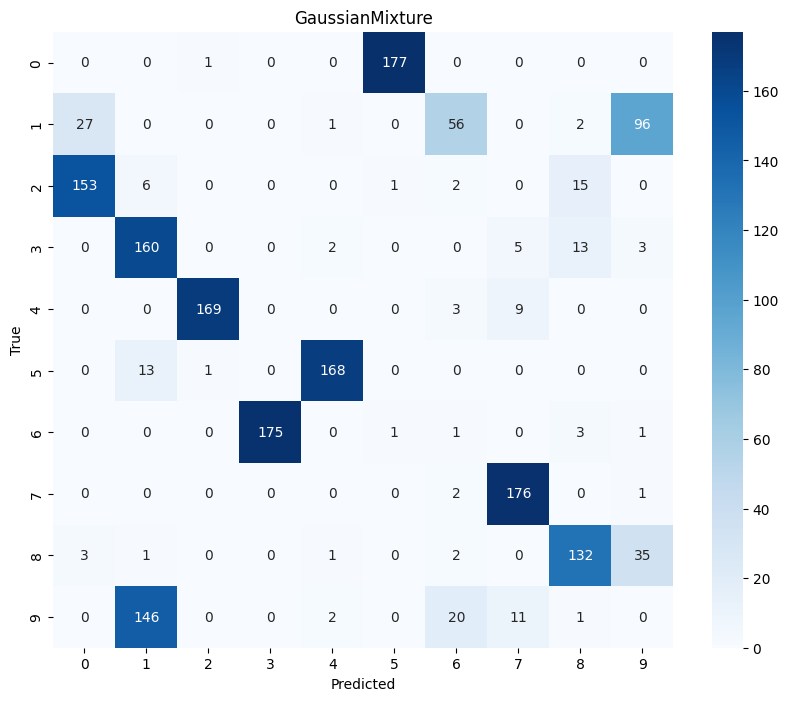

In [23]:
cm_gmm = confusion_matrix(y, y_pred_gmm_pca)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_gmm, annot=True, fmt='d', cmap='Blues')
plt.title('GaussianMixture')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [24]:
row_ind, col_ind = linear_sum_assignment(cm_gmm.max() - cm_gmm)

cluster_to_digit = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}

for cluster_id in sorted(cluster_to_digit.keys()):
    digit = cluster_to_digit[cluster_id]
    print(f"Кластер {cluster_id} → Цифра {digit}")

y_pred_mapped_gmm = np.array([cluster_to_digit[i] for i in y_pred_gmm_pca])

Кластер 0 → Цифра 2
Кластер 1 → Цифра 3
Кластер 2 → Цифра 4
Кластер 3 → Цифра 6
Кластер 4 → Цифра 5
Кластер 5 → Цифра 0
Кластер 6 → Цифра 9
Кластер 7 → Цифра 7
Кластер 8 → Цифра 8
Кластер 9 → Цифра 1


In [25]:
_gmm = sum(y==y_pred_mapped_gmm)/len(y_pred_mapped_gmm)
print(f"{_gmm:.2f}")

0.79


In [26]:
spectral = SpectralClustering(
    n_clusters=10,
    affinity='nearest_neighbors',
    n_neighbors=10,
    random_state=42
)
y_pred_spectral_pca = spectral.fit_predict(X_pca)

In [27]:
ari_spectral_pca = adjusted_rand_score(y, y_pred_spectral_pca)
print(f"{ari_spectral_pca:.2f}")

0.76


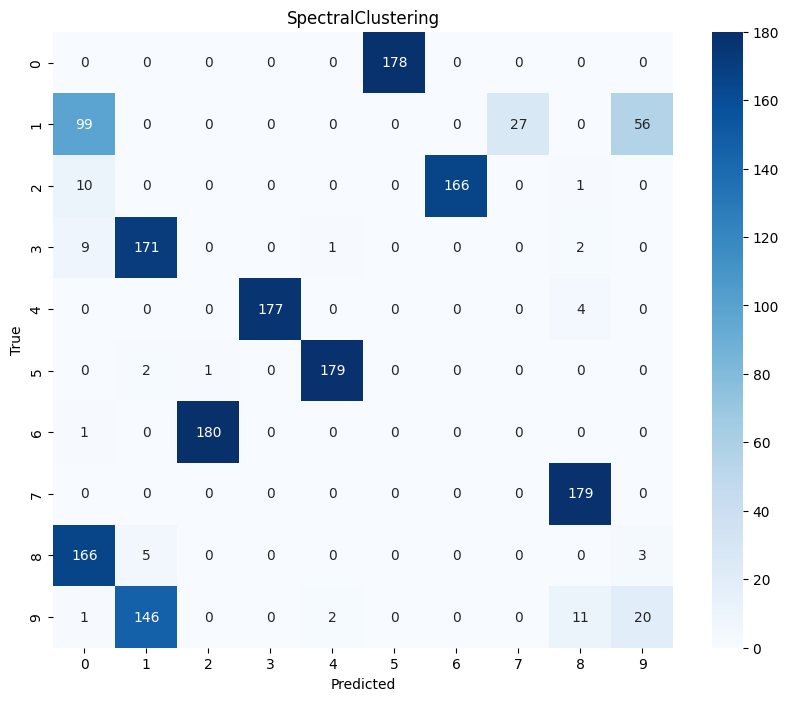

In [28]:
cm_spectral = confusion_matrix(y, y_pred_spectral_pca)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_spectral, annot=True, fmt='d', cmap='Blues')
plt.title('SpectralClustering')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [29]:
row_ind, col_ind = linear_sum_assignment(cm_spectral.max() - cm_spectral)

cluster_to_digit = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}

for cluster_id in sorted(cluster_to_digit.keys()):
    digit = cluster_to_digit[cluster_id]
    print(f"Кластер {cluster_id} → Цифра {digit}")

y_pred_mapped_spectral = np.array([cluster_to_digit[i] for i in y_pred_spectral_pca])

Кластер 0 → Цифра 8
Кластер 1 → Цифра 3
Кластер 2 → Цифра 6
Кластер 3 → Цифра 4
Кластер 4 → Цифра 5
Кластер 5 → Цифра 0
Кластер 6 → Цифра 2
Кластер 7 → Цифра 9
Кластер 8 → Цифра 7
Кластер 9 → Цифра 1


In [30]:
_spectral = sum(y==y_pred_mapped_spectral)/len(y_pred_mapped_spectral)
print(f"{_spectral:.2f}")

0.81


In [31]:
birch = Birch(
    n_clusters=10,
    threshold=0.5,
    branching_factor=50
)
y_pred_birch_pca = birch.fit_predict(X_pca)

In [32]:
ari_birch_pca = adjusted_rand_score(y, y_pred_birch_pca)
print(f"{ari_birch_pca:.2f}")

0.74


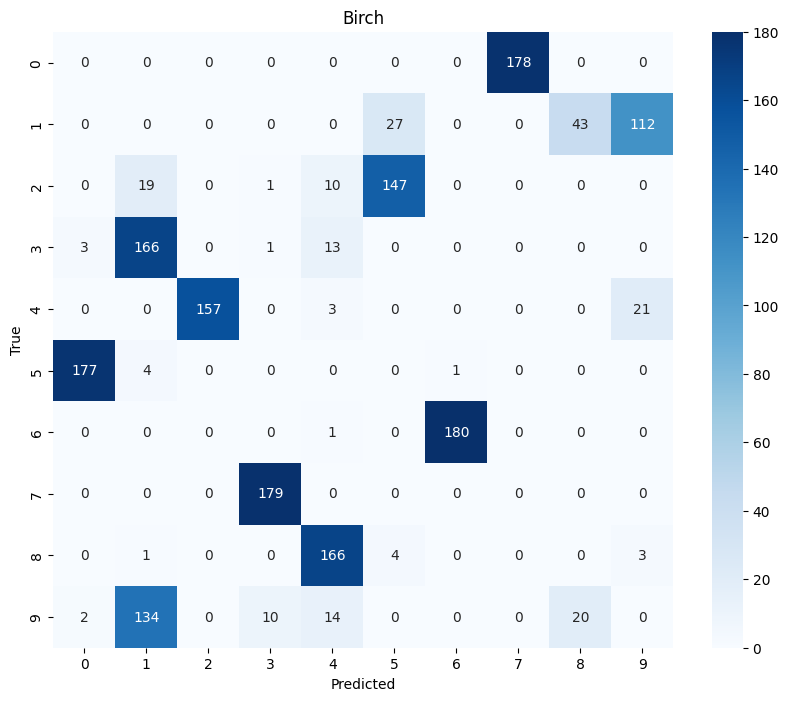

In [33]:
cm_birch = confusion_matrix(y, y_pred_birch_pca)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_birch, annot=True, fmt='d', cmap='Blues')
plt.title('Birch')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [34]:
row_ind, col_ind = linear_sum_assignment(cm_birch.max() - cm_birch)

cluster_to_digit = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}

for cluster_id in sorted(cluster_to_digit.keys()):
    digit = cluster_to_digit[cluster_id]
    print(f"Кластер {cluster_id} → Цифра {digit}")

y_pred_mapped_birch = np.array([cluster_to_digit[i] for i in y_pred_birch_pca])

Кластер 0 → Цифра 5
Кластер 1 → Цифра 3
Кластер 2 → Цифра 4
Кластер 3 → Цифра 7
Кластер 4 → Цифра 8
Кластер 5 → Цифра 2
Кластер 6 → Цифра 6
Кластер 7 → Цифра 0
Кластер 8 → Цифра 9
Кластер 9 → Цифра 1


In [35]:
_birch = sum(y==y_pred_mapped_birch)/len(y_pred_mapped_birch)
print(f"{_birch:.2f}")

0.82


In [38]:
results = pd.DataFrame({
    'Метод': [
        'KMeans',
        'GaussianMixture',
        'SpectralClustering',
        'Birch'
    ],
    'Точность': [
        _kmeans,
        _gmm,
        _spectral,
        _birch
    ],
    'ARI': [
        ari_pca,
        ari_pca_gmm,
        ari_spectral_pca,
        ari_birch_pca
    ]
})

results['Точность'] = results['Точность'].round(2)
results['ARI'] = results['ARI'].round(2)

print(results[['Метод', 'Точность', 'ARI']].to_string(index=False))

             Метод  Точность  ARI
            KMeans      0.79 0.66
   GaussianMixture      0.79 0.71
SpectralClustering      0.81 0.76
             Birch      0.82 0.74
